In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
BG = "#0f1117"
PANEL = "#1c1f26"
TEXT = "#e6e6e6"

plt.style.use("default")
target = "Depression"

Loading the dataset

In [3]:
file_path = "data/house_price_50k.csv"

df = pd.read_csv(file_path)

# Remove extra white space from columns
df.columns = df.columns.str.strip()

# Exploratory Data Analysis
Displaying the first 5 rows of data

In [4]:
df.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1.792425e+06


Statistical Overview of Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

In [6]:
df.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04
mean,2752.970540,3.496040,2.498040,1.997060,19.573740,14.968700,0.500540,0.497300,0.500280,0.496220,0.501100,0.498320,0.498320,0.500040,5.006444,5065.94598,1.030261e+06
std,1297.148134,1.712146,1.117704,0.815368,11.552502,8.363714,0.500005,0.499998,0.500005,0.499991,0.500004,0.500002,0.500002,0.500005,2.876776,2864.34322,4.580199e+05
min,500.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000311,100.00000,9.090069e+04
25%,1630.000000,2.000000,1.000000,1.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.523018,2575.00000,6.357375e+05
50%,2756.000000,3.000000,2.000000,2.000000,20.000000,15.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.022946,5060.50000,1.031763e+06
75%,3872.000000,5.000000,3.000000,3.000000,30.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.479632,7543.00000,1.423102e+06
max,4999.000000,6.000000,4.000000,3.000000,39.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999869,9999.00000,1.996474e+06


Checking data types

In [7]:
df.dtypes

area                      int64
bedrooms                  int64
bathrooms                 int64
floors                    int64
age                       int64
distance                  int64
garage                    int64
parking                   int64
garden                    int64
security                  int64
school_nearby             int64
hospital_nearby           int64
shopping_mall_nearby      int64
public_transport          int64
crime_rate              float64
population_density        int64
location                 object
income_level             object
price                   float64
dtype: object

Checking data columns

In [9]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'garage',
       'parking', 'garden', 'security', 'school_nearby', 'hospital_nearby',
       'shopping_mall_nearby', 'public_transport', 'crime_rate',
       'population_density', 'location', 'income_level', 'price'],
      dtype='object')

Checking missing values

In [10]:
missing_values = df.isnull().sum()
missing_values

area                    0
bedrooms                0
bathrooms               0
floors                  0
age                     0
distance                0
garage                  0
parking                 0
garden                  0
security                0
school_nearby           0
hospital_nearby         0
shopping_mall_nearby    0
public_transport        0
crime_rate              0
population_density      0
location                0
income_level            0
price                   0
dtype: int64

Checking duplicated values

In [11]:
duplicated_values = df.duplicated().sum()
duplicated_values

np.int64(0)

Heatmap Correlation

In [12]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

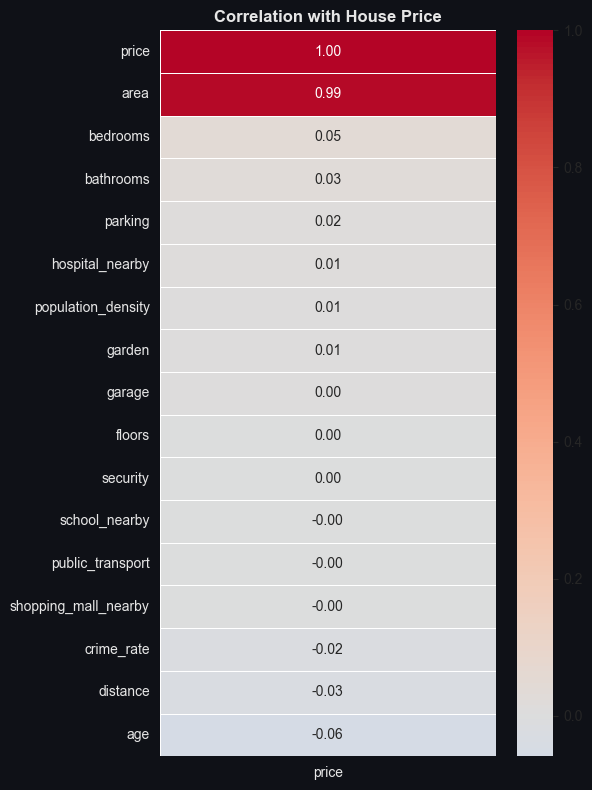

In [13]:
target = "price"

corr_target = numerical_df.corr(numeric_only=True)[[target]].sort_values(by=target, ascending=False)

plt.figure(figsize=(6, 8), facecolor=BG)
ax = plt.gca()
ax.set_facecolor(PANEL)

sns.heatmap(
    corr_target,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0,
    cbar=True
)

ax.set_title("Correlation with House Price", color=TEXT, fontweight='bold')
ax.tick_params(colors=TEXT)

plt.tight_layout()
plt.show()

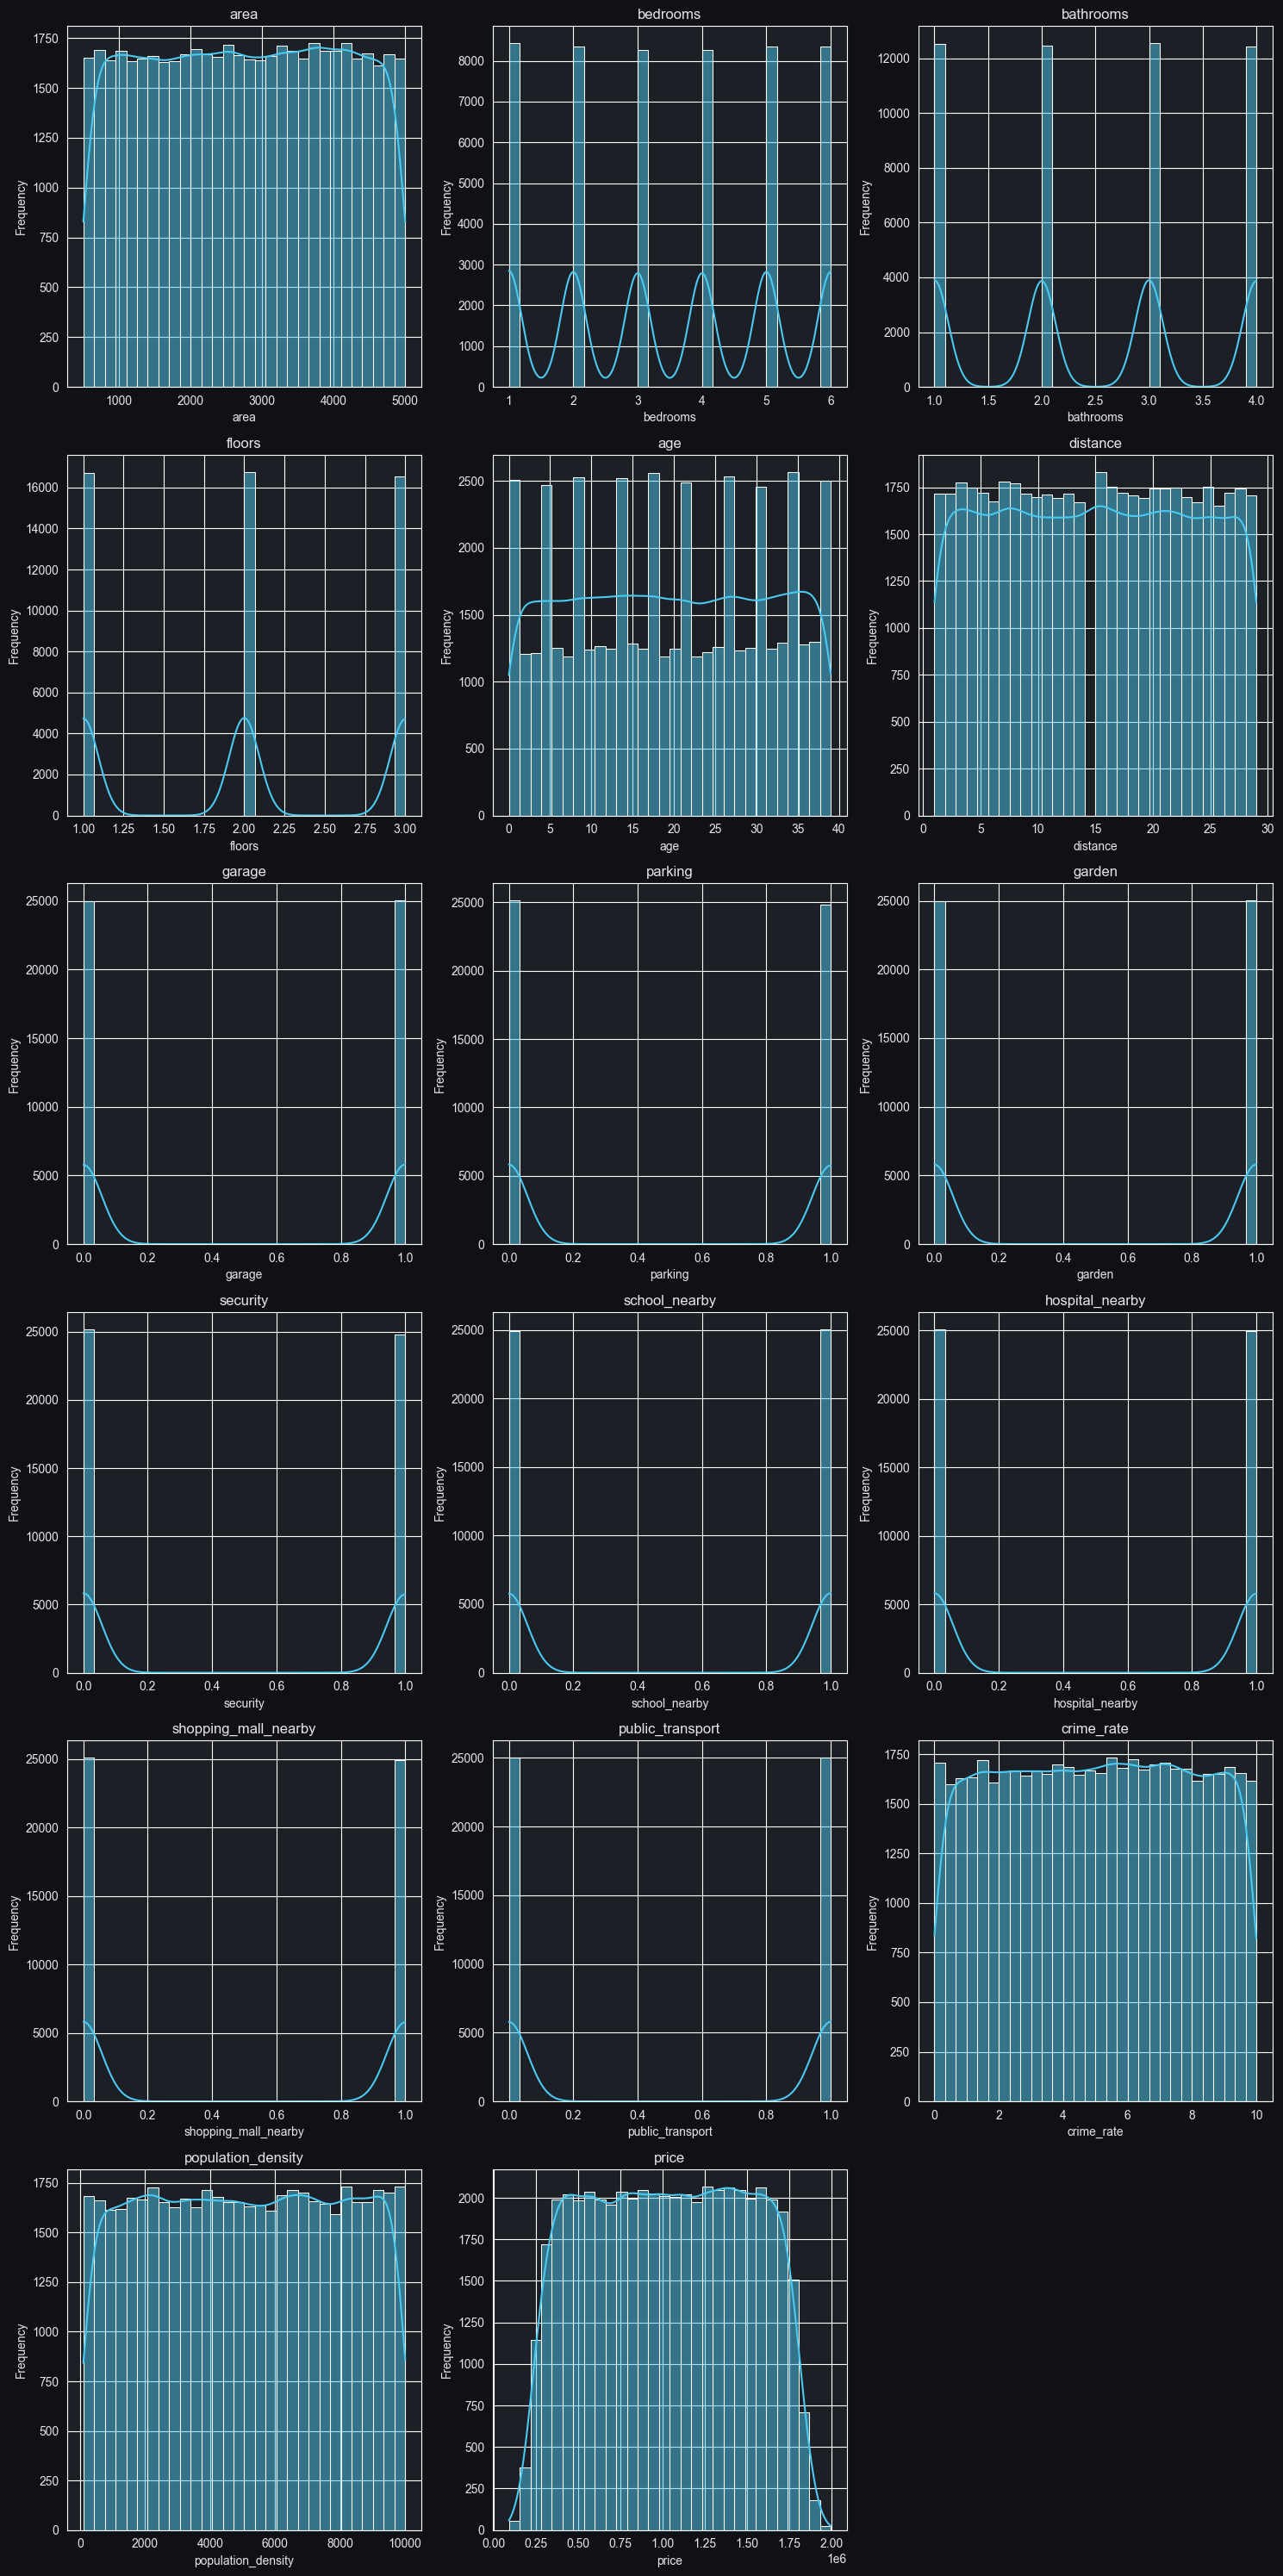

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numeric columns
cols = numerical_df.columns
n = len(cols)

# Grid siz
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# Set the dark background
fig.patch.set_facecolor(BG)

for i, col in enumerate(cols):
    ax = axes[i]

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color="#4cc9f0",  # plain blue color
        ax=ax
    )

    ax.set_title(f"{col}", color=TEXT)
    ax.set_xlabel(col, color=TEXT)
    ax.set_ylabel("Frequency", color=TEXT)

    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)

# Remove empty plots if any at all
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

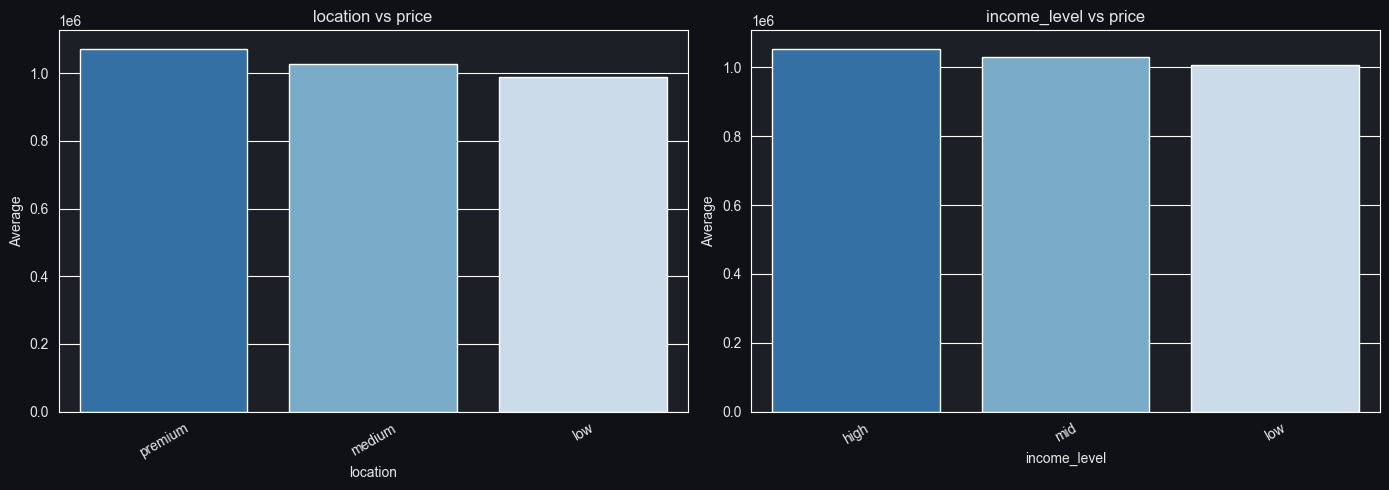

In [15]:
target_col = "price"

# Select categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

n = len(cat_cols)
n_cols = 2
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

fig.patch.set_facecolor(BG)

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Aggregate + sort
    agg = (
        df.groupby(col)[target_col]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(
    data=agg,
    x=col,
    y=target_col,
    hue=col,           # add this
    palette="Blues_r",
    errorbar="ci",
    legend=False,      # and this
    ax=ax
)

    # Styling
    ax.set_title(f"{col} vs {target_col}", color=TEXT)
    ax.set_xlabel(col, color=TEXT)
    ax.set_ylabel("Average", color=TEXT)

    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    ax.tick_params(axis='x', rotation=30)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Machine Learning
Preprocessing Data

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
X = df.drop("price", axis=1)
Y = df["price"]

# Scale-fit Transformation
X_scaled = StandardScaler().fit_transform(X)

Splitting data into training and testing sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

Training the Model

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the model
model = RandomForestRegressor(random_state=42)

# Initialize Grid Search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# Train the model with the best parameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Evaluate the model
predictions = best_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Outputting the results
print(f"r2 Score: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
r2 Score: 1.00
Mean Squared Error: 802395675.88
Mean Absolute Error: 22650.65


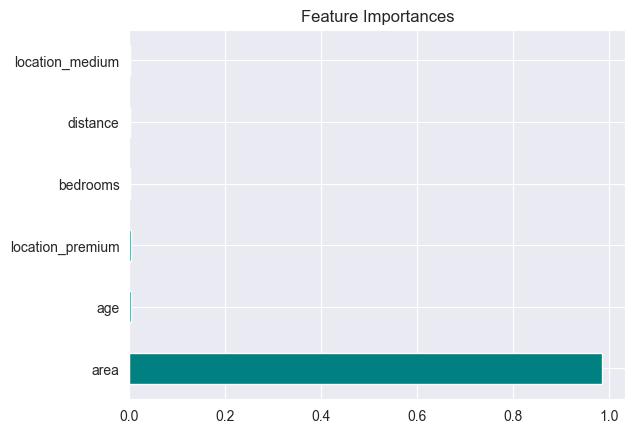

In [21]:
# Visualizing the importance of the top 6 largest columns
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importances.nlargest(6).plot(kind="barh", color="teal")
plt.title("Feature Importances")
plt.show()

In [22]:
import joblib

with open("models/house_price_mode.pkl", "wb") as model:
    joblib.dump(best_model, model)